In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

from collections import Counter
from omegaconf import OmegaConf
from pathlib import Path

from beyond_hate.analysis.validate_annotations import validate_annotations
from beyond_hate.analysis.utils import parse_labels, majority_vote_binary, majority_vote_multilabel, sanitize


INCIVILITY_CATEGORIES = {0: "Civil", 1: "Vulgar", 2: "Attacks", 3: "Aspersions"}

INTOLERANCE_CATEGORIES = {
    0: "Tolerant",
    1: "Threats to Rights",
    2: "Political Intolerance",
    3: "Racism",
    4: "Social Intolerance",
    5: "Gender Intolerance",
    6: "Religious Intolerance",
    7: "Offensive Stereotypes",
    8: "Violent Threats",
    9: "Ableism",
}


# Add project to path
project_root = Path("../..").resolve()
 
# Load configuration
config_path = project_root / 'config/default.yaml'
cfg = OmegaConf.load(config_path)

# Output directory for plots
outdir = project_root / cfg.out.path / "analysis_finegrained"
outdir.mkdir(exist_ok=True)

print("Configuration loaded successfully")

Configuration loaded successfully


In [3]:
# Build paths
labels_file = project_root / cfg.data.paths.labels_file
images_to_annotate_file = project_root / cfg.data.paths.base / "images_to_annotate.txt"
hf_data_path = project_root / cfg.data.paths.hf

# Load relevant ids
with open(images_to_annotate_file, "r") as f:
    lines = f.readlines()
    relevant_ids = [int(line.strip()) for line in lines]

print(f"Loaded {len(relevant_ids)} relevant image IDs")

Loaded 2030 relevant image IDs


In [4]:
# Load annotations and keep only relevant ones
annotations = pd.read_json(labels_file, lines=True,
                           dtype={"label_hateful": int,
                                  "label_incivility": str,
                                  "label_intolerance": str})
# Filter annotations to keep only those with relevant IDs
annotations = annotations[annotations["id"].isin(relevant_ids)]
# Validate annotations
annotations = validate_annotations(annotations, relevant_ids)

2026-03-18 10:08:41 - validate_annotations - INFO - Validating annotations...
2026-03-18 10:08:41 - validate_annotations - INFO - Annotation validation complete


### Analysis 1: Raw Counts

In [5]:
from beyond_hate.analysis.utils import parse_labels

incivility_labels = parse_labels(annotations['label_incivility'])
intolerance_labels = parse_labels(annotations['label_intolerance'])

incivility_labels_counts = Counter(incivility_labels)
intolerance_labels_counts = Counter(intolerance_labels)

# Create DataFrame for counts
incivility_df = pd.DataFrame({
    "category": [INCIVILITY_CATEGORIES[i] for i in range(len(INCIVILITY_CATEGORIES))],
    "count": [incivility_labels_counts[i] for i in range(len(INCIVILITY_CATEGORIES))]
})
intolerance_df = pd.DataFrame({
    "category": [INTOLERANCE_CATEGORIES[i] for i in range(len(INTOLERANCE_CATEGORIES))],
    "count": [intolerance_labels_counts[i] for i in range(len(INTOLERANCE_CATEGORIES))]
})

intolerance_df["share"] = intolerance_df["count"] / intolerance_df["count"].sum()
incivility_df["share"] = incivility_df["count"] / incivility_df["count"].sum()

In [6]:
intolerance_df["count"].sum()

np.int64(6670)

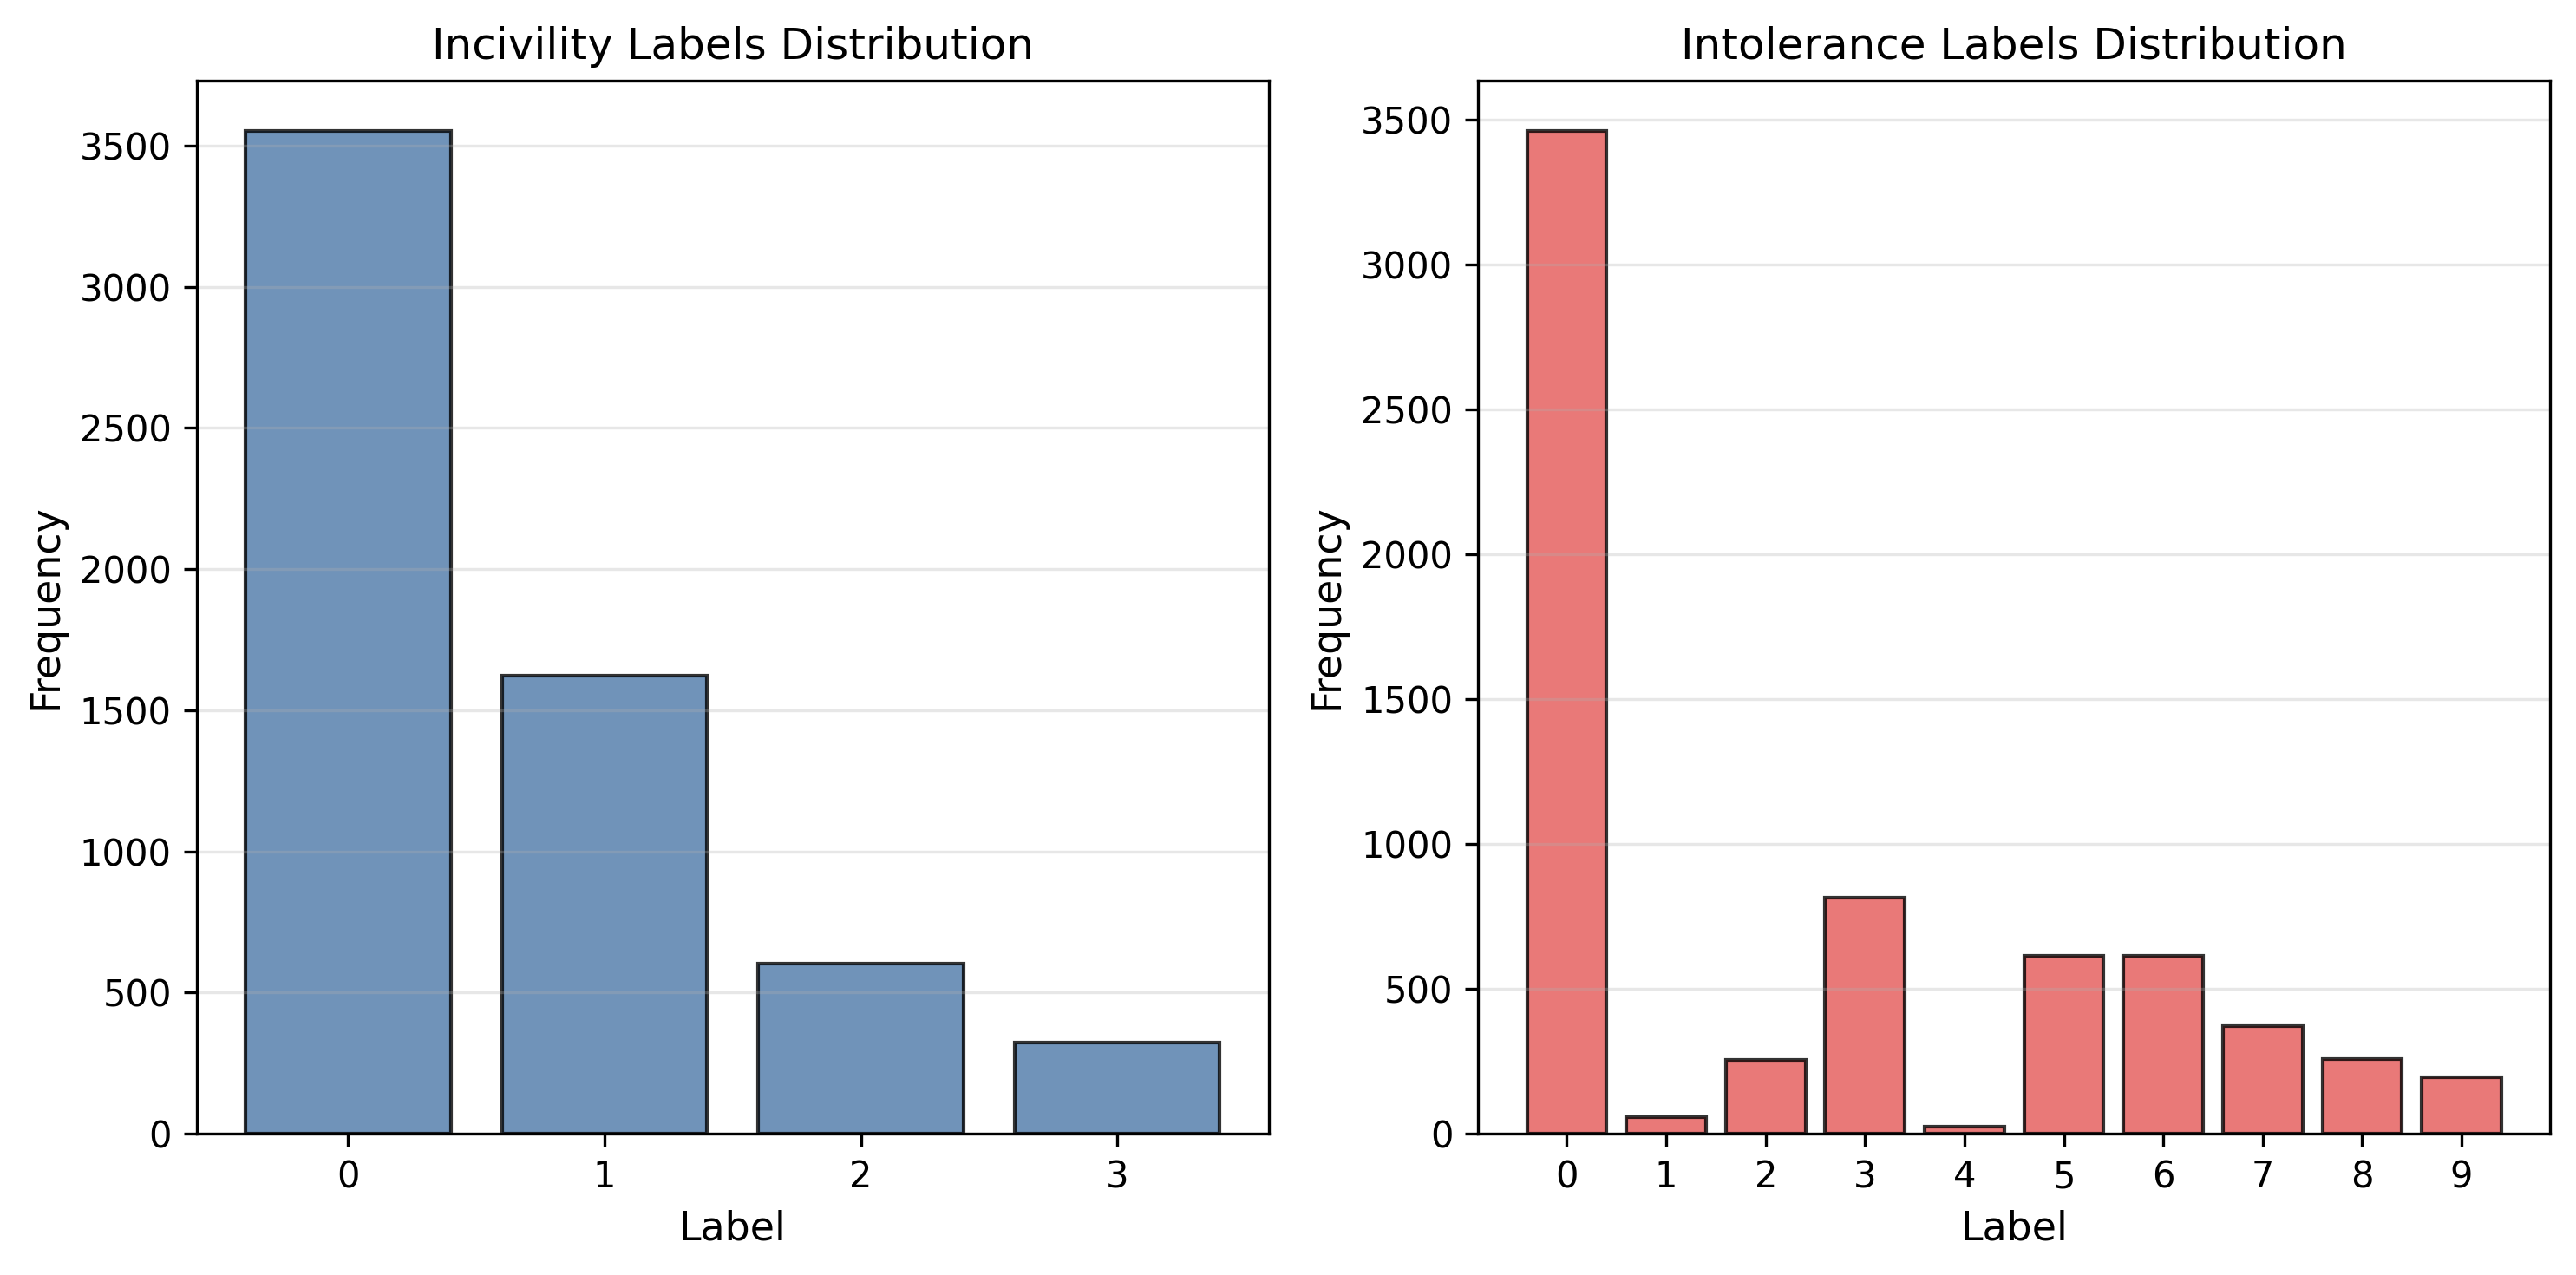

In [7]:
# Plot histograms of incivility and intolerance labels
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

# Incivility histogram
labels_incivility = sorted(incivility_labels_counts.keys())
counts_incivility = [incivility_labels_counts[label] for label in labels_incivility]

axes[0].bar(labels_incivility, counts_incivility, color='#4C78A8', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Label', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Incivility Labels Distribution', fontsize=12)
axes[0].set_xticks(labels_incivility)
axes[0].grid(axis='y', alpha=0.3)

# Intolerance histogram
labels_intolerance = sorted(intolerance_labels_counts.keys())
counts_intolerance = [intolerance_labels_counts[label] for label in labels_intolerance]

axes[1].bar(labels_intolerance, counts_intolerance, color='#E45756', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Label', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Intolerance Labels Distribution', fontsize=12)
axes[1].set_xticks(labels_intolerance)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(outdir / "labels_frequency.png", dpi=300)
plt.show()

### Analysis 2: Majority Vote Labels

In [8]:
# Binary aggregation
binary_cols = ["label_hateful", "label_incivility_bin", "label_intolerance_bin"]

binary_agg = annotations.groupby("id")[binary_cols].agg(majority_vote_binary)

# Multilabel aggregation
incivility_agg = (
    annotations.groupby("id")["label_incivility"]
    .apply(lambda x: majority_vote_multilabel(x, INCIVILITY_CATEGORIES))
    .unstack()
)

incivility_agg.columns = [f"incivility_{c}" for c in incivility_agg.columns]

intolerance_agg = (
    annotations.groupby("id")["label_intolerance"]
    .apply(lambda x: majority_vote_multilabel(x, INTOLERANCE_CATEGORIES))
    .unstack()
)

intolerance_agg.columns = [f"intolerance_{c}" for c in intolerance_agg.columns]

final_df = binary_agg.join(incivility_agg).join(intolerance_agg).reset_index()

In [38]:
# Analyze correlation between categories and hateful label
categories = [c for c in final_df.columns if c.startswith("incivility_") or c.startswith("intolerance_")]

analysis = []
for col in categories:
    subset = final_df[final_df[col] == 1]
    if len(subset) == 0:
        continue
    p_hate = subset["label_hateful"].mean()
    analysis.append(
        {"category": col, "n": len(subset), "P(hateful | category)": p_hate}
    )

analysis_df = pd.DataFrame(analysis).sort_values(
    "P(hateful | category)", ascending=False
)

analysis_df["phi"] = [
    final_df[col].corr(final_df["label_hateful"])
    for col in analysis_df["category"]
]
# Beutify for latex
analysis_df[["type", "category"]] = analysis_df["category"].str.split("_", n=1, expand=True)
analysis_df = analysis_df.round(2)
analysis_df["category"] = analysis_df["category"].str.replace("_", " ")
analysis_df = analysis_df[["type", "category", "n", "P(hateful | category)", "phi"]]
analysis_df = analysis_df.sort_values("type", ascending=True)

In [39]:
analysis_df.to_latex(outdir / "granular_majority_vote.tex",
                     label="tab:granular_majority_vote",
                     caption="Correlation of fine-grained categories with hateful label (majority vote aggregation).",
                     float_format='{:.2f}'.format,
                     index=False)

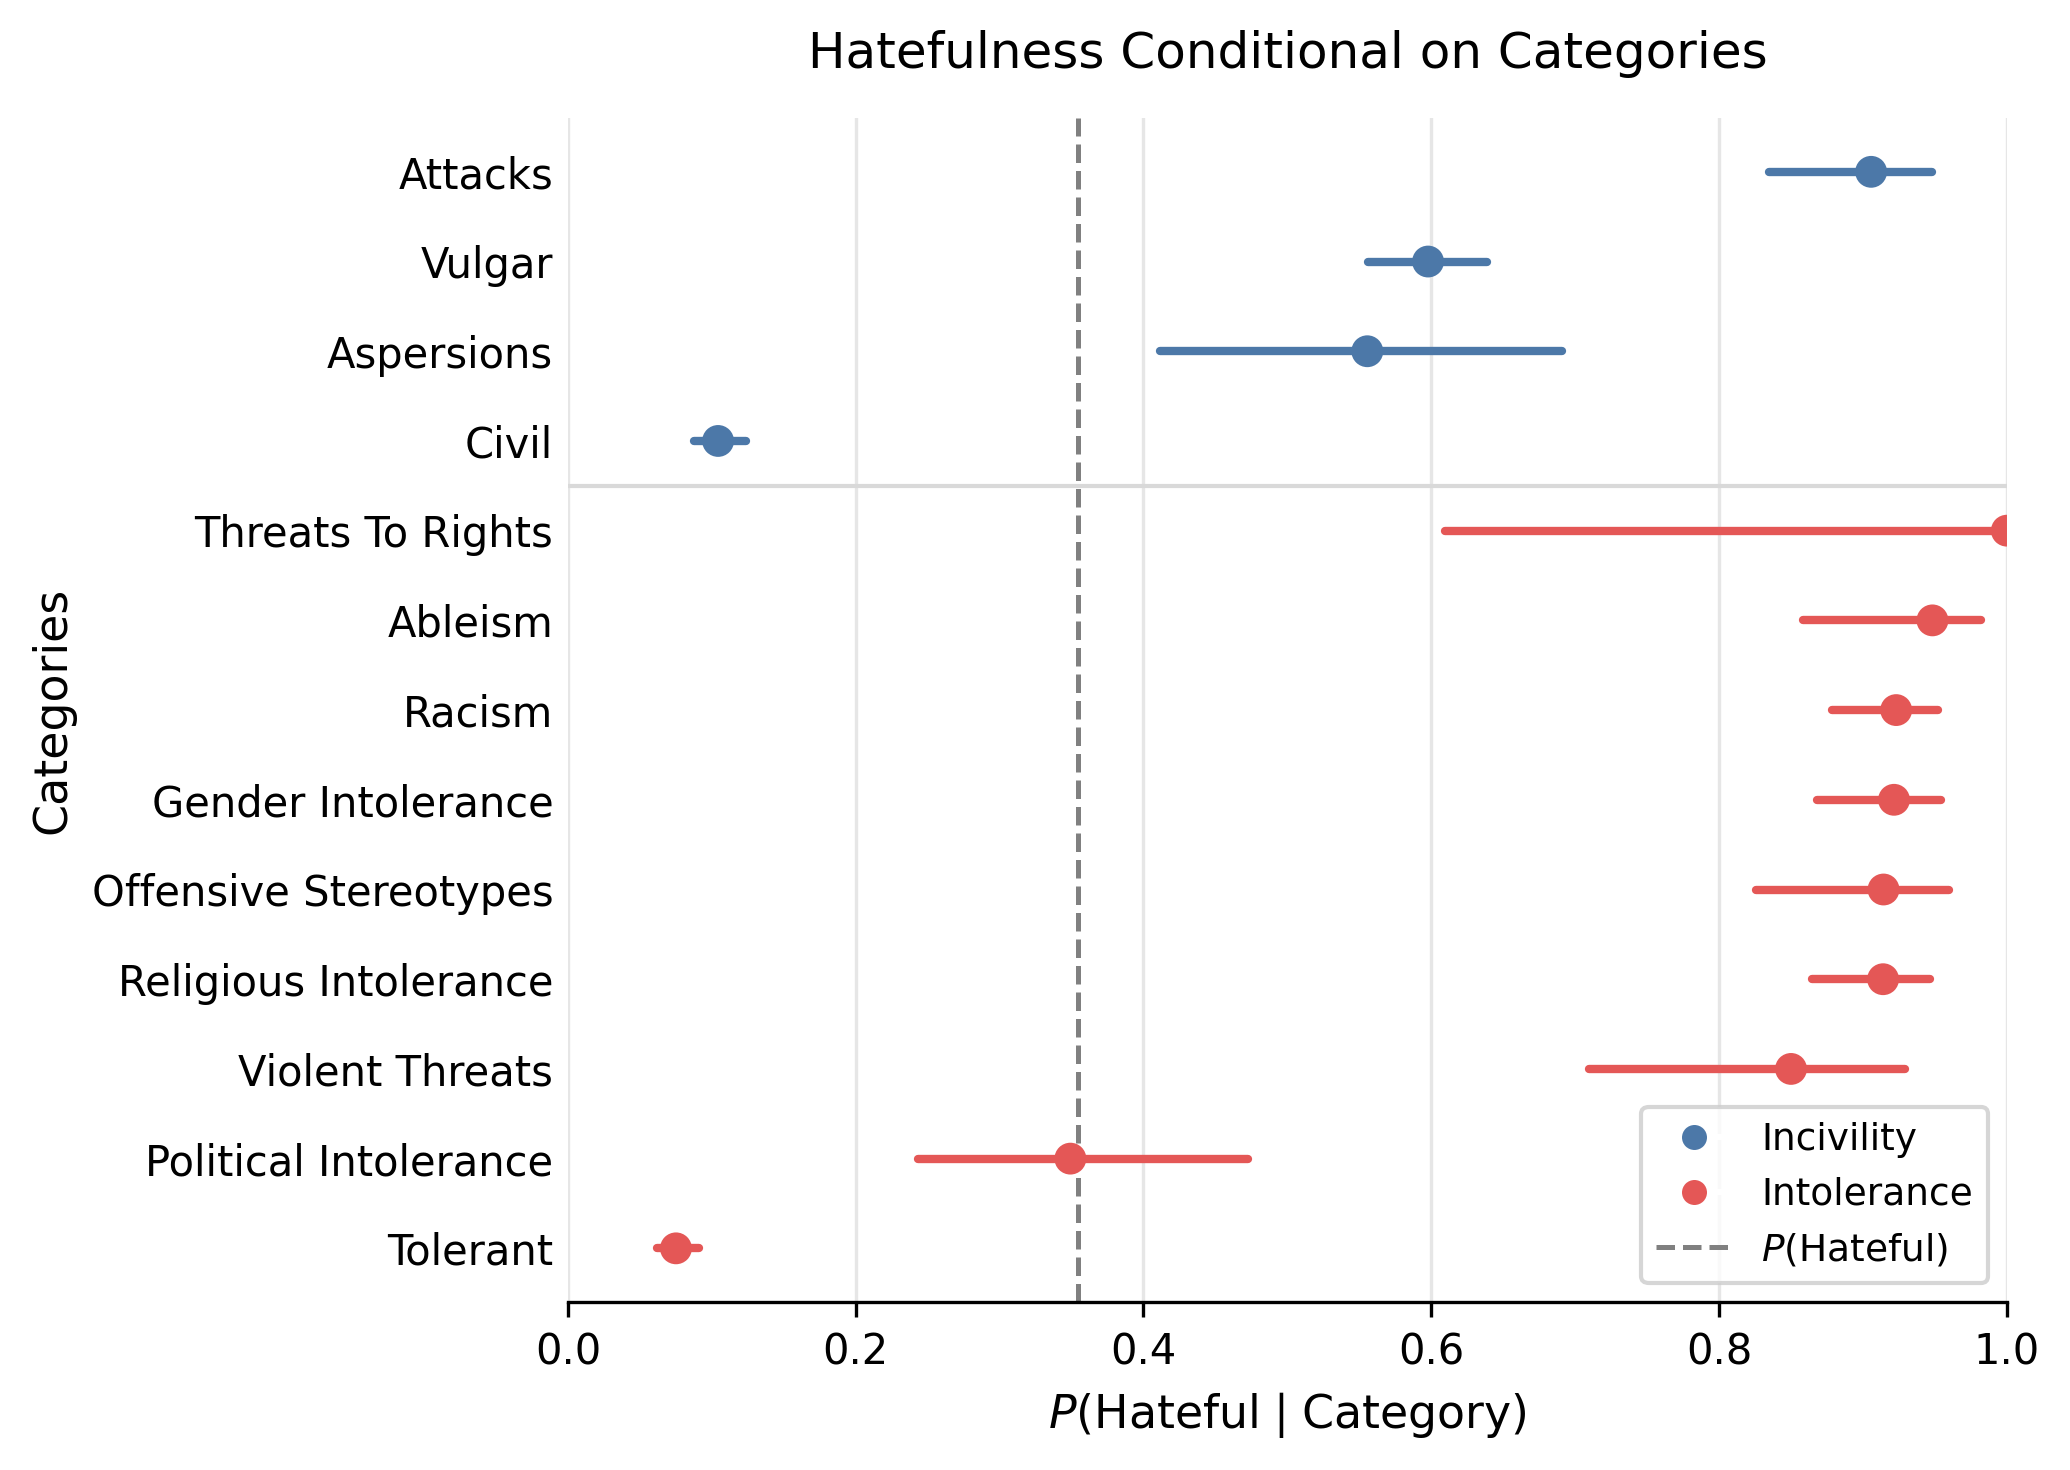

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from statsmodels.stats.proportion import proportion_confint

# category columns
category_cols = [
    c for c in final_df.columns
    if c.startswith("incivility_") or c.startswith("intolerance_")
]

# build plot dataframe
rows = []
for col in category_cols:
    subset = final_df[final_df[col] == 1]
    n = len(subset)
    if n == 0:
        continue

    k = subset["label_hateful"].sum()
    p = k / n
    lower, upper = proportion_confint(k, n, alpha=0.05, method="wilson")

    rows.append({
        "term": col,
        "capture_rate": p,
        "lower": lower,
        "upper": upper,
        "n": n
    })

plot_df = pd.DataFrame(rows)

# labels and groups
label_map = {
    "incivility_attacks": "Attacks",
    "incivility_vulgar_profane": "Vulgar/profane",
    "incivility_aspersions": "Aspersions",
    "incivility_civil": "Civil",
    "intolerance_threats_to_rights": "Threats to rights",
    "intolerance_political_intolerance": "Political intolerance",
    "intolerance_racism": "Racism",
    "intolerance_social_economic_intolerance": "Socioeconomic intolerance",
    "intolerance_gender_sexual_intolerance": "Gender/sexual intolerance",
    "intolerance_religious_intolerance": "Religious intolerance",
    "intolerance_offensive_stereotypes": "Offensive stereotypes",
    "intolerance_violent_threats": "Violent threats",
    "intolerance_ableism": "Ableism",
    "intolerance_tolerant": "Tolerant",
}

plot_df["label"] = (plot_df["term"].str.replace("incivility_", "")
                                   .str.replace("intolerance_", "")
                                   .str.replace("_", " ")
                                   .str.title()
                                   )

plot_df["group"] = np.where(
    plot_df["term"].str.startswith("incivility_"),
    "Incivility",
    "Intolerance"
)

# optional but recommended: remove baseline categories from the main plot
# plot_df = plot_df[~plot_df["term"].isin(["incivility_Civil", "intolerance_Tolerant"])].copy()

# sort descending within group
plot_df = pd.concat([
    plot_df[plot_df["group"] == "Incivility"].sort_values("capture_rate", ascending=False),
    plot_df[plot_df["group"] == "Intolerance"].sort_values("capture_rate", ascending=False)
]).reset_index(drop=True)

colors = plot_df["group"].map({
    "Incivility": "#4C78A8",
    "Intolerance": "#E45756"
})

base_rate = final_df["label_hateful"].mean()

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# confidence intervals
for i, row in plot_df.iterrows():
    ax.plot(
        [row["lower"], row["upper"]], [i, i],
        color=colors.iloc[i], lw=2.0, solid_capstyle="round", zorder=2
    )

# points
ax.scatter(
    plot_df["capture_rate"], range(len(plot_df)),
    c=colors, s=44, zorder=3
)

# overall hate rate
ax.axvline(base_rate, color="0.5", linestyle="--", linewidth=1.2, zorder=1)

# separator between groups
inciv_n = (plot_df["group"] == "Incivility").sum()
if 0 < inciv_n < len(plot_df):
    ax.axhline(inciv_n - 0.5, color="0.85", lw=1)

# axes
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["label"], fontsize=10)
ax.invert_yaxis()

ax.set_xlim(0, 1.0)
ax.set_xlabel("$P(\\mathrm{Hateful}\\mid\\mathrm{Category})$", fontsize=11)
ax.set_ylabel("Categories", fontsize=11)
ax.set_title("Hatefulness Conditional on Categories", fontsize=12, pad=12)

# styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", color="0.9", linewidth=0.8)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", length=0)

# legend outside
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Incivility',
           markerfacecolor="#4C78A8", markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Intolerance',
           markerfacecolor="#E45756", markersize=7),
    Line2D([0], [0], color="0.5", lw=1.2, linestyle="--",
           label="$P(\\mathrm{Hateful})$"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(outdir / "hateful_cond_cat.png", dpi=300)
plt.show()

### Analysis 3: Logistic Regression

In [11]:
df = annotations.copy()

def majority_vote(series):
    return int(series.mean() >= 0.5)

def expand_multilabel(series, categories, prefix):
    """
    Convert comma-separated labels into probability distribution
    where each annotator contributes weight 1 split across labels.
    """
    counts = {k: 0.0 for k in categories.keys()}

    for item in series.dropna():
        labels = [int(x) for x in item.split(",")]
        weight = 1 / len(labels)

        for l in labels:
            counts[l] += weight

    total = sum(counts.values())

    if total == 0:
        return {f"{prefix}_{sanitize(categories[k])}": 0 for k in categories}

    return {
        f"{prefix}_{sanitize(categories[k])}": counts[k] / total
        for k in categories
    }


rows = []

for meme_id, g in df.groupby("id"):
    row = {"id": meme_id}

    # binary majority vote
    row["hateful"] = majority_vote(g["label_hateful"])
    row["incivility_bin"] = majority_vote(g["label_incivility_bin"])
    row["intolerance_bin"] = majority_vote(g["label_intolerance_bin"])

    # probability distributions
    inciv = expand_multilabel(
        g["label_incivility"],
        INCIVILITY_CATEGORIES,
        "incivility"
    )
    row.update(inciv)

    intoler = expand_multilabel(
        g["label_intolerance"],
        INTOLERANCE_CATEGORIES,
        "intolerance"
    )
    row.update(intoler)

    rows.append(row)

agg_df = pd.DataFrame(rows)


# ---- Logistic regression ----
inciv_cols = [c for c in agg_df.columns if c.startswith("incivility_") and not c.endswith("_bin")]
intol_cols = [c for c in agg_df.columns if c.startswith("intolerance_") and not c.endswith("_bin")]

# drop baseline category
inciv_cols = [c for c in inciv_cols if "Civil" not in c]
intol_cols = [c for c in intol_cols if "Tolerant" not in c]

X = agg_df[inciv_cols + intol_cols]
y = agg_df["hateful"]

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())
with open('regression_summary.txt', 'w') as f:
    f.write(str(result.summary()))

Optimization terminated successfully.
         Current function value: 0.258994
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                hateful   No. Observations:                 2030
Model:                          Logit   Df Residuals:                     2017
Method:                           MLE   Df Model:                           12
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                  0.6015
Time:                        10:08:43   Log-Likelihood:                -525.76
converged:                       True   LL-Null:                       -1319.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -4.2101      0.181    -23

In [12]:
# extract regression table
summary_table = result.summary2().tables[1]

# compute odds ratios
summary_table["odds_ratio"] = np.exp(summary_table["Coef."])

# compute CI for odds ratios
summary_table["OR_2.5%"] = np.exp(summary_table["[0.025"])
summary_table["OR_97.5%"] = np.exp(summary_table["0.975]"])

summary_table

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],odds_ratio,OR_2.5%,OR_97.5%
const,-4.210132,0.181449,-23.202876,4.258763e-119,-4.565765,-3.854499,0.014844,0.010402,0.021184
incivility_Vulgar,1.786265,0.247077,7.229596,4.844320e-13,1.302003,2.270526,5.967122,3.676655,9.684494
incivility_Attacks,2.015546,0.493987,4.080163,4.500420e-05,1.047350,2.983742,7.504826,2.850088,19.761635
incivility_Aspersions,0.606533,0.557252,1.088436,2.764025e-01,-0.485660,1.698726,1.834062,0.615291,5.466978
intolerance_Threats_to_Rights,5.314654,1.394105,3.812234,1.377164e-04,2.582259,8.047049,203.294172,13.226980,3124.562194
intolerance_Political_Intolerance,1.793626,0.572590,3.132479,1.733367e-03,0.671371,2.915882,6.011212,1.956917,18.465094
intolerance_Racism,6.073193,0.424947,14.291638,2.467373e-46,5.240312,6.906075,434.064626,188.728969,998.321033
intolerance_Social_Intolerance,4.544001,2.021581,2.247747,2.459235e-02,0.581776,8.506227,94.066429,1.789213,4945.466223
intolerance_Gender_Intolerance,5.274579,0.397898,13.256114,4.158972e-40,4.494713,6.054444,195.308178,89.542495,426.002030
intolerance_Religious_Intolerance,5.765670,0.449359,12.830868,1.101229e-37,4.884942,6.646398,319.152784,132.282780,770.005733


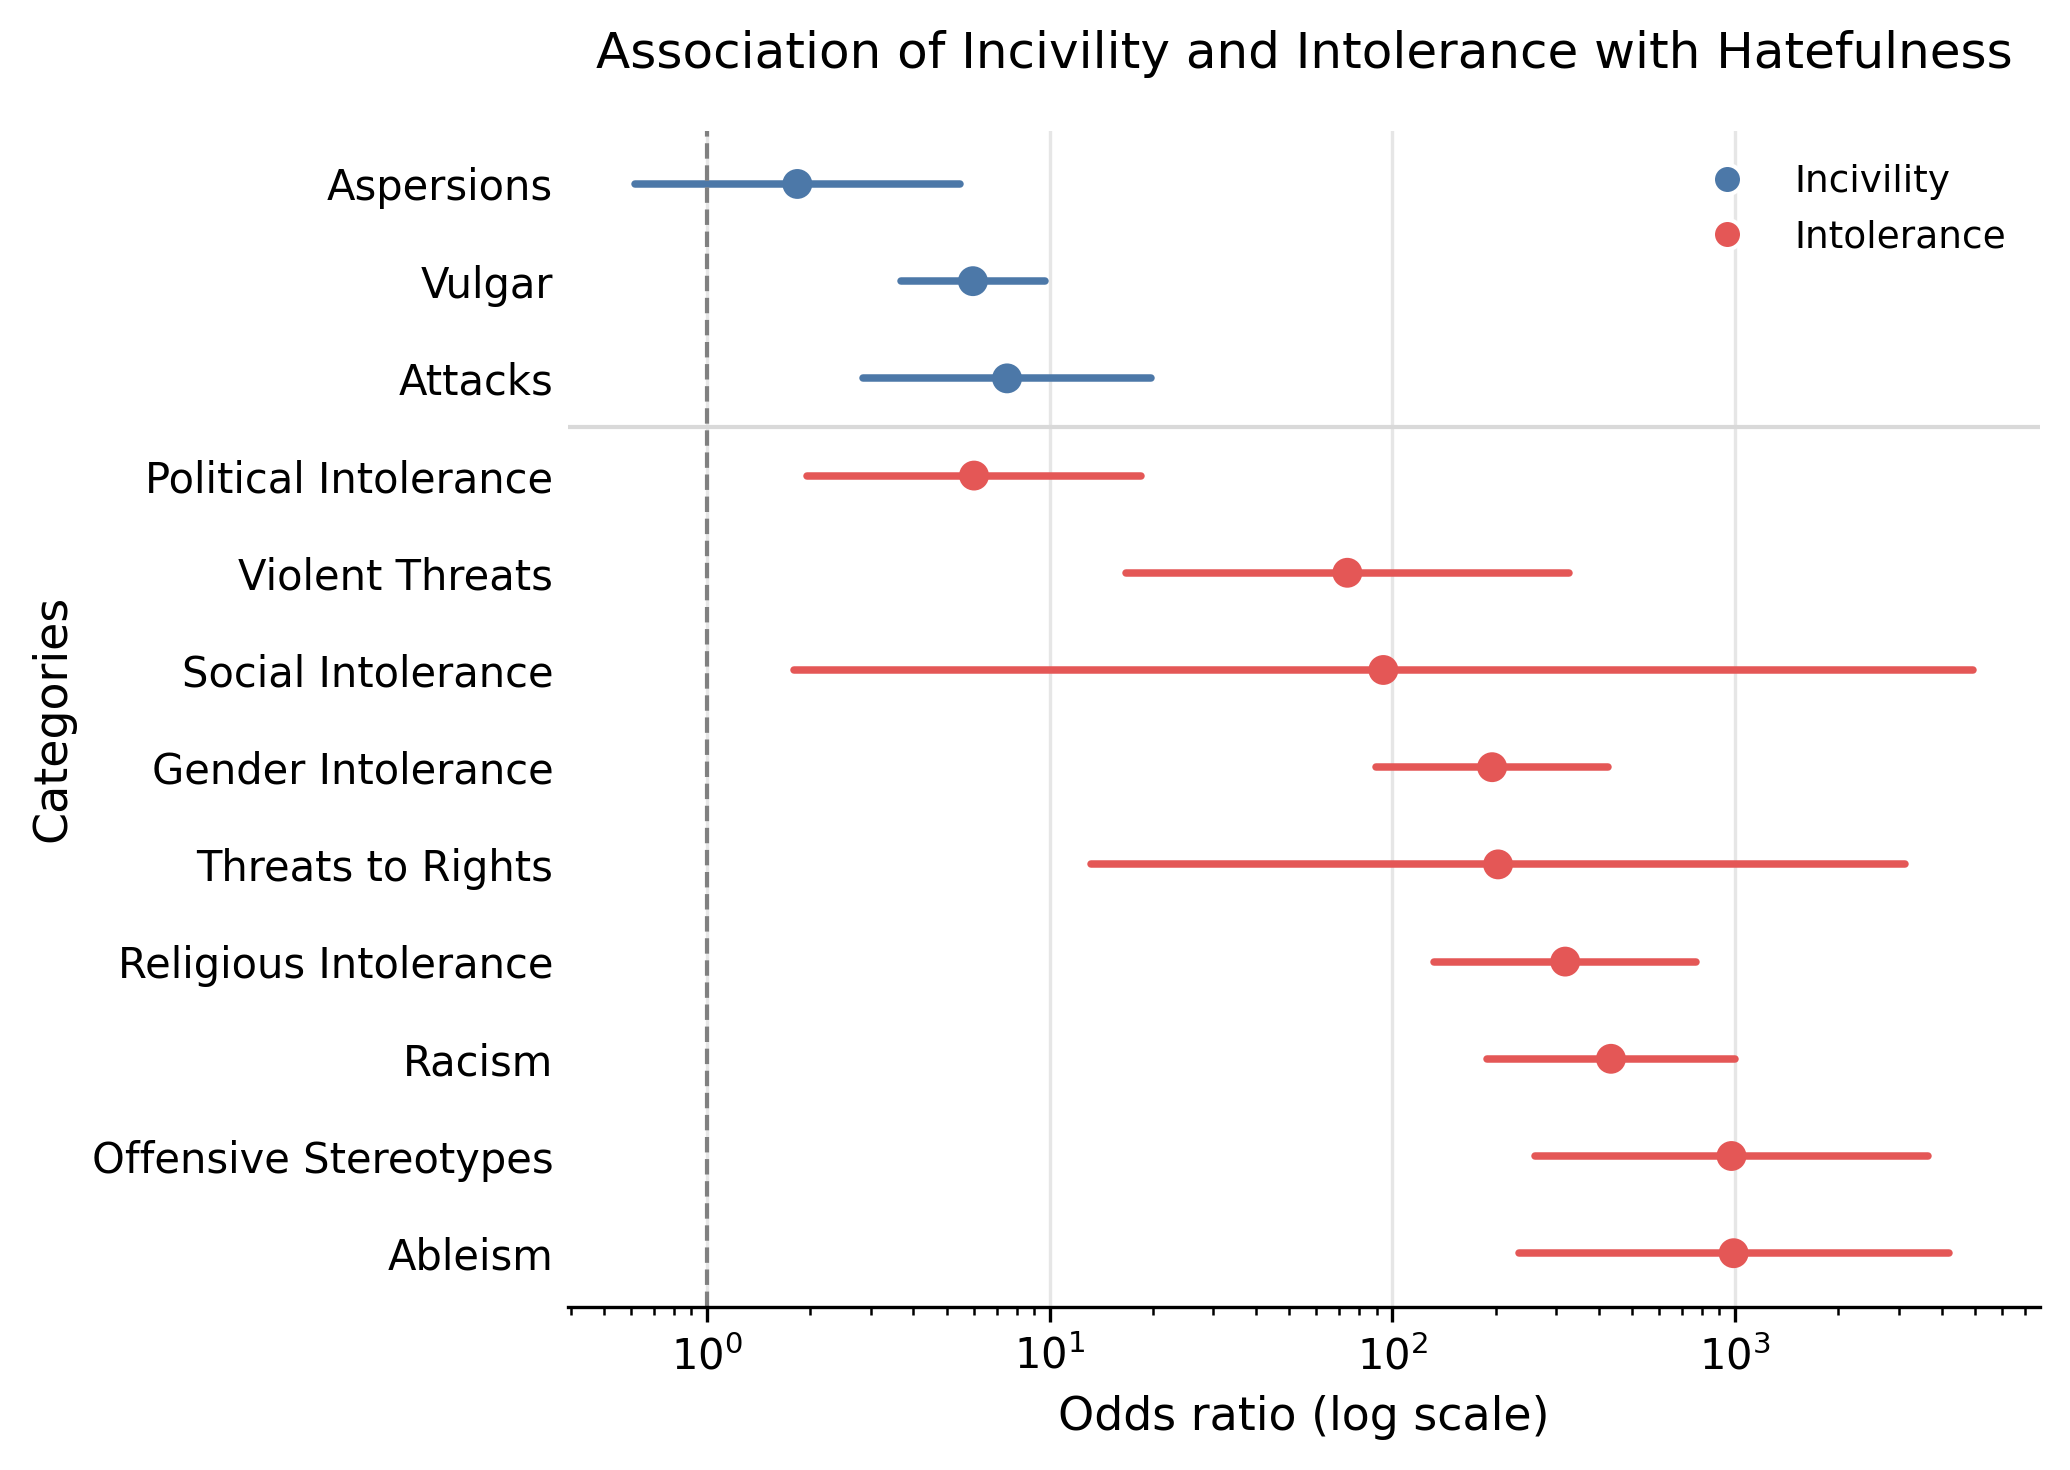

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

coef = result.params.drop("const")
conf = result.conf_int().drop("const")
conf.columns = ["lower", "upper"]

plot_df = pd.DataFrame({
    "term": coef.index,
    "or": np.exp(coef.values),
    "lower": np.exp(conf["lower"].values),
    "upper": np.exp(conf["upper"].values)
})

plot_df["label"] = (
    plot_df["term"]
    .str.replace("incivility_", "", regex=False)
    .str.replace("intolerance_", "", regex=False)
    .str.replace("_", " ", regex=False)
)

plot_df["group"] = plot_df["term"].apply(
    lambda x: "Incivility" if x.startswith("incivility_") else "Intolerance"
)

plot_df = pd.concat([
    plot_df[plot_df["group"] == "Incivility"].sort_values("or"),
    plot_df[plot_df["group"] == "Intolerance"].sort_values("or")
]).reset_index(drop=True)

colors = plot_df["group"].map({
    "Incivility": "#4C78A8",
    "Intolerance": "#E45756"
})

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
ax.set_title("Association of Incivility and Intolerance with Hatefulness", fontsize=12, pad=15)

for i, row in plot_df.iterrows():
    ax.plot([row["lower"], row["upper"]], [i, i],
            color=colors.iloc[i], lw=1.8, solid_capstyle="round")

ax.scatter(plot_df["or"], range(len(plot_df)), c=colors, s=38, zorder=3)

ax.axvline(1, color="0.5", linestyle="--", linewidth=1)

ax.set_xscale("log")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["label"], fontsize=10)
ax.invert_yaxis()

ax.set_xlabel("Odds ratio (log scale)", fontsize=11)
ax.set_ylabel("Categories", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", color="0.9", linewidth=0.8)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", length=0)

inciv_end = (plot_df["group"] == "Incivility").sum() - 0.5
if inciv_end >= 0:
    ax.axhline(inciv_end, color="0.85", lw=1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Incivility',
           markerfacecolor="#4C78A8", markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Intolerance',
           markerfacecolor="#E45756", markersize=7),
]
ax.legend(handles=legend_elements, frameon=False, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(outdir / "regression_odds_ratios.png", dpi=300)
plt.show()